# 이미지 분류

### 데이터 전처리

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])


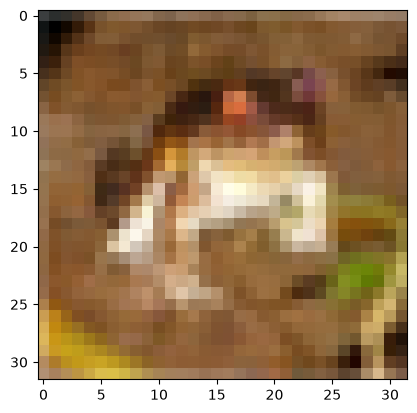

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

import pickle

## 이미지 데이터를 파일로 부터 읽어오는 함수
def unpickle(file):
    with open(file,'rb') as ff:
        data = pickle.load(ff, encoding='bytes')
    return data

## 이미지데이터 <- 파일
batch = unpickle("../fff/cifar-10-batches-py/data_batch_1")

print(batch.keys())

## 이미지들
images = batch[b'data']

#print(images.shape)  ## (10000, 3072)  10000장 이미지  3072 데이터 : 32*32*3

import numpy as np
import matplotlib.pyplot as plt

## 이미지1개 추출
imgOne = images[0]
imgOne = imgOne.reshape(3,32,32)
#imgOne

imgOne = np.transpose(imgOne,(1,2,0)) # 32,32,3 형태로 변경

## 이미지 그리
plt.imshow(imgOne)
plt.show()





In [36]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

import pickle

## 이미지 데이터를 파일로 부터 읽어오는 함수
def unpickle(file):
    with open(file,'rb') as ff:
        data = pickle.load(ff, encoding='bytes')
    return data
#--------------------------------------------
## 학습 데이터 만들기
#--------------------------------------------
train_images=[]     #이미지들
train_labels=[]     #이미지이름들

for i in range(1,6):
    batch = unpickle(f"../fff/cifar-10-batches-py/data_batch_{i}")
    train_images.append(batch[b'data'])
    train_labels.extend(batch[b'labels'])
    
#train_images
#train_labels
    
##5개 파일로 나누어서 들어간 배열들을 붙이기    
## []원소10000 개 배열 * 5  ==> [] 원소 50000 개
train_images=np.concatenate(train_images)    
train_labels=np.array(train_labels)    
#print(train_labels)
#train_images.shape  #(50000, 3072)
## 모양바꾸기 (이미지 형태로 변환)
train_images = train_images.reshape(-1,3,32,32) # (50000, 3, 32, 32)
train_images = np.transpose(train_images,(0,2,3,1)) # (50000, 32, 32, 3)
#train_images.shape



#--------------------------------------------
## 테스트 데이터 만들기
#--------------------------------------------
batch = unpickle(f"../fff/cifar-10-batches-py/test_batch")
test_images=batch[b'data']
test_labels=np.array(batch[b'labels']) 

## 모양바꾸기 (이미지 형태로 변환)
test_images = test_images.reshape(-1,3,32,32) # (10000, 3, 32, 32)
test_images = np.transpose(test_images,(0,2,3,1)) # (10000, 32, 32, 3)
#test_images


#--------------------------------------------
## tensorFlow 형태
#--------------------------------------------
dataset = (
    (train_images, train_labels),
    (test_images, test_labels)
)

print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)


(50000, 32, 32, 3)
(50000,)
(10000, 32, 32, 3)
(10000,)


In [37]:
##  정규화 작업
print(train_images[0])
print("-----------------")
train_images = train_images / 255.0     ## 100분율 작업
test_images = test_images / 255.0

print(train_images[0])


[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
-----------------
[[[0.23137255 0.24313725 0.24705882]
  [0.16862745 0.18039216 0.17647059]
  [0.19607843 0.18823529 0.16862745]
  ...
  [0.61960784 0.51764706 0.42352941]
  [0.59607843 0.49019608 0.4       ]
  [0.58039216 0.48627451 0.40392157]]

 [[0.0627451  0.07843137 0.07843137]
  [0.         0.         0.        ]
  [0.07058824 0.03137255 0.        ]
  ...
  [0.

In [38]:
### 학습데이터 --> 훈련데이터 /  검증데이터 로 구분
##검증데이터
val_images = train_images[45000:]
val_labels = train_labels[45000:]

## 훈련데이터
train_images = train_images[:45000]
train_labels = train_labels[:45000]

In [40]:
from tensorflow.keras.layers import Dense , Flatten

## 모델 생성
model = tf.keras.models.Sequential([
    Flatten(input_shape=(32,32,3)),     ## 입력층 (32,32,3) ==> 3072
    Dense(512, activation='relu'),      ## 은닉층 1  뉴런 512 -> 음수:0, 양수 그냥통과
    Dense(256, activation='relu'),      ## 은닉층 2  뉴런 256 -> 음수:0, 양수 그냥통과
    Dense(128, activation='relu'),      ## 은닉층 3  뉴런 128 -> 음수:0, 양수 그냥통과
                                        ## 중요한 특징(구분할수 있는 특징) 만 추출
    Dense(10, activation='softmax'),    ## 출력층  :: 종류가 10개
])
'''
비행기, 오토바이, 새, 고양이, 사슴, 개, 개구리, 말 배, 트럭
'''
## 모델 구조 확인
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
## 모델 컴파일
model.compile(
    optimizer='adam',                           ## 경사하강법 가중치 수정
    loss='sparse_categorical_crossentropy',     ## 손실함수
            ## 다중 클래스 (분류가 10개 : 분류 레이블 숫자형태)
    metrics= ['accuracy']       ## 평가지표
)

In [42]:
## 모델 학습 시작
model.fit(
    train_images,          ## 학습용 입력데이터(x)
    train_labels,           # 학습용 정답데이터(y)
    epochs = 5,             # 전체 학습 5번 반복
    validation_data=(
        val_images,         # 검증 입력 데이터
        val_labels          # 검증 정답 데이터
    )
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3218 - loss: 1.8781 - val_accuracy: 0.3640 - val_loss: 1.7487
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3923 - loss: 1.6919 - val_accuracy: 0.4242 - val_loss: 1.6275
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4225 - loss: 1.6033 - val_accuracy: 0.4352 - val_loss: 1.5898
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4463 - loss: 1.5477 - val_accuracy: 0.4236 - val_loss: 1.5812
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4571 - loss: 1.5121 - val_accuracy: 0.4650 - val_loss: 1.5221


In [43]:
## 모델 평가
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4580 - loss: 1.5271


[1.527145504951477, 0.4580000042915344]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[0.00689287 0.00120941 0.5462018  0.05264641 0.18975265 0.07975982
  0.07426557 0.04690394 0.00149586 0.00087161]]
예측: 2 새
실제: 2 새


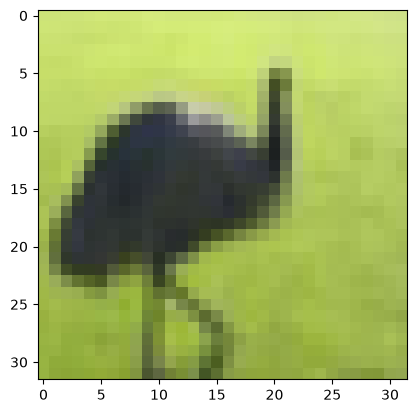

[[[0.80392157 0.89019608 0.47058824]
  [0.80392157 0.89019608 0.47058824]
  [0.80784314 0.89411765 0.4745098 ]
  ...
  [0.81960784 0.89411765 0.5372549 ]
  [0.81176471 0.88627451 0.5372549 ]
  [0.80784314 0.88235294 0.5372549 ]]

 [[0.80784314 0.89803922 0.4627451 ]
  [0.80784314 0.89411765 0.4627451 ]
  [0.80392157 0.89019608 0.45882353]
  ...
  [0.82745098 0.90196078 0.52941176]
  [0.81960784 0.89411765 0.53333333]
  [0.81568627 0.89411765 0.52941176]]

 [[0.79607843 0.88627451 0.44705882]
  [0.79607843 0.88235294 0.44705882]
  [0.79215686 0.87843137 0.44313725]
  ...
  [0.80784314 0.88627451 0.49803922]
  [0.80392157 0.87843137 0.50196078]
  [0.8        0.87843137 0.50196078]]

 ...

 [[0.58823529 0.69803922 0.25490196]
  [0.59215686 0.69803922 0.25882353]
  [0.56862745 0.67843137 0.23529412]
  ...
  [0.61960784 0.70980392 0.30980392]
  [0.63137255 0.71764706 0.31372549]
  [0.6        0.68627451 0.29803922]]

 [[0.59607843 0.70588235 0.25882353]
  [0.56078431 0.67058824 0.22745098]


In [ ]:
## 예측
no = 123
imgOne = test_images[no]

prediction = model.predict(np.expand_dims(imgOne, axis=0))
print(prediction)
## 가장 높은 확률 클래스(결과)
res = np.argmax(prediction)

class_title = ('비행기', '오토바이', '새','고양이', '사슴', '개', '개구리', '말', '배', '트럭')

print("예측:",res,class_title[res])
print("실제:",test_labels[no],class_title[test_labels[no]])
#plt.imshow(imgOne)  ## 정규화되어서 소숫점으로 수치화 되어 검정색으로 나옴
plt.imshow((imgOne*255).astype('uint8'))
plt.show()
#print(imgOne)